# Arrival model tuning charts (sketch)

Cheap **scalar / decomposition** matplotlib prototypes for the PR #78 arrival **settings pane** (Preview tier). Each chart pairs 1:1 with a studio slider and updates from closed-form Λ, analytic gamma scalars, Poisson pmf, φ(T) Q10, and tiny precomputed grids — **no** full Prior PDF rebake, **no** `rung_law_on_grid`, **no** `arrival_marginal_cdf_py` on slider moves.

**Defaults** load from `data/abdella/arrival_model.json` (ρ=0.08, τ̄=0.5 d, T_break=12 °C, q10=1.5, gamma k/θ/reference_life).


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import gammainc, gammaincc
from scipy.stats import poisson

%matplotlib inline

REPO = Path.cwd().resolve()
if not (REPO / "src" / "blueberries_voi").is_dir():
    REPO = REPO.parent
assert (REPO / "data" / "abdella" / "arrival_model.json").is_file(), REPO

ARTIFACT_PATH = REPO / "data" / "abdella" / "arrival_model.json"
ARTIFACT = json.loads(ARTIFACT_PATH.read_text())

K = float(ARTIFACT["gamma_shape"])
THETA = float(ARTIFACT["gamma_scale"])
ETA_REF = float(ARTIFACT["reference_life_days"])
Q10 = float(ARTIFACT["q10"])
T_REF = float(ARTIFACT["T_ref"])
RHO_DEF = float(ARTIFACT["rho"])
TAU_BAR_DEF = float(ARTIFACT["tau_bar"])
T_BREAK_DEF = float(ARTIFACT["T_break"])

D_MED = 5.5
D_BAR = 5.5
LAMBDA_FLOOR = 1e-6


def phi(t_c, q10: float = Q10, t_ref: float = T_REF):
    """Q10 store-temperature factor (matches `store_temp_factor`)."""
    t_arr = np.asarray(t_c, dtype=float)
    return np.power(q10, (t_arr - t_ref) / 10.0)


def phi_set_from_legs(artifact: dict, bias_c: float = 0.0) -> float:
    """Duration-weighted leg φ with optional uniform ΔT bias on setpoints."""
    return sum(
        leg["weight"] * phi(leg["setpoint_c"] + bias_c, artifact["q10"], artifact["T_ref"])
        for leg in artifact["legs"]
    )


def phi_break(t_break: float, artifact: dict | None = None) -> float:
    art = ARTIFACT if artifact is None else artifact
    return phi(t_break, art["q10"], art["T_ref"])


def break_exposure_rate(phi_set: float, phi_brk: float) -> float:
    return max(phi_brk - phi_set, 0.0)


def lambda_clean(d: float, phi_set: float) -> float:
    return max(d * phi_set, LAMBDA_FLOOR)


def lambda_with_breaks(
    d: float,
    n_breaks: int,
    tau_bar: float,
    phi_set: float,
    phi_brk: float,
) -> float:
    """Λ for `n_breaks` mean-duration breaks (τ̄ each)."""
    ber = break_exposure_rate(phi_set, phi_brk)
    return max(d * phi_set + n_breaks * tau_bar * ber, LAMBDA_FLOOR)


def lambda_expected(
    d: float,
    rho: float,
    tau_bar: float,
    phi_set: float,
    phi_brk: float,
) -> float:
    """E[Λ] under Poisson(ρd) breaks × Exp(τ̄) durations."""
    ber = break_exposure_rate(phi_set, phi_brk)
    return max(d * phi_set + rho * d * tau_bar * ber, LAMBDA_FLOOR)


def p_f_zero(lam: float, k: float = K, theta: float = THETA) -> float:
    a = k * max(lam, LAMBDA_FLOOR)
    return float(gammaincc(a, 1.0 / theta))


def p_f_below(lam: float, f_cut: float, k: float = K, theta: float = THETA) -> float:
    a = k * max(lam, LAMBDA_FLOOR)
    return float(gammaincc(a, (1.0 - f_cut) / theta))


def mean_f(lam: float, k: float = K, theta: float = THETA, eta_ref: float = ETA_REF) -> float:
    _ = eta_ref  # reference_life pins θ via k·θ·η_ref = 1 in the artifact
    a = k * max(lam, LAMBDA_FLOOR)
    p0 = gammaincc(a, 1.0 / theta)
    survive = 1.0 - p0
    ed_below1 = a * theta * (1.0 - gammaincc(a + 1.0, 1.0 / theta))
    return float(survive - ed_below1)


def mean_setpoint_c(artifact: dict, bias_c: float = 0.0) -> float:
    return sum(leg["weight"] * (leg["setpoint_c"] + bias_c) for leg in artifact["legs"])


PHI_SET_DEF = phi_set_from_legs(ARTIFACT)
PHI_BREAK_DEF = phi_break(T_BREAK_DEF)


## Chart 1 — `preview_transit_days` → Freshness thermometer

Pack date pins calendar transit duration **d** for the Preview tier: the studio slider `preview_transit_days` (2–7 d) is the single knob a merchandiser turns when asking “what if this lot sat in transit one more day?”. Under a **clean chain** (no breaks) cumulative exposure is simply Λ ≈ **d·φ_set**, so moving the slider slides Λ linearly without touching the break lottery or rebaking the full arrival Prior.

The bullet/gauge plots **E[f | Λ]** on [0, 1] with a secondary band for **P(f < 0.5)** — both from the shape-scaled gamma law Gamma(k·Λ, θ) with f = 1 − D (matching `voi_core` `p_f_zero` / `cdf_f_given_lambda`). One gamma mean and two regularized incomplete-gamma calls per slider position; no quadrature.

| Variable | Role |
|----------|------|
| `preview_transit_days` | Studio slider (2–7 d); sketch uses **5.5 d** default |
| `d` | Calendar transit days |
| `φ_set` | Duration-weighted Q10 factor at leg setpoints |
| `Λ` | `d · φ_set` (clean chain) |
| `E[f\|Λ]`, `P(f<0.5)` | Gamma scalar summaries at Λ |


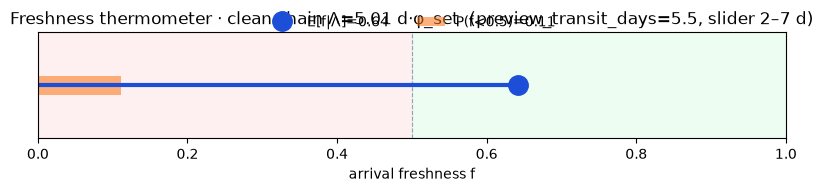

In [2]:
preview_d = 5.5
phi_set = PHI_SET_DEF
lam = lambda_clean(preview_d, phi_set)
mf = mean_f(lam)
p_lo = p_f_below(lam, 0.5)

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axhspan(0, 1, xmin=0, xmax=0.5, color="#fee2e2", alpha=0.5, zorder=0)
ax.axhspan(0, 1, xmin=0.5, xmax=1.0, color="#dcfce7", alpha=0.5, zorder=0)
ax.axvline(0.5, color="#94a3b8", ls="--", lw=0.8, zorder=1)
ax.barh(0.5, p_lo, height=0.18, color="#f97316", alpha=0.55, label=f"P(f<0.5)={p_lo:.2f}")
ax.plot([mf], [0.5], "o", color="#1d4ed8", ms=14, zorder=3, label=f"E[f|Λ]={mf:.2f}")
ax.plot([0, mf], [0.5, 0.5], color="#1d4ed8", lw=3, zorder=2)
ax.set_yticks([])
ax.set_xlabel("arrival freshness f")
ax.set_title(
    f"Freshness thermometer · clean chain Λ={lam:.2f} d·φ_set  "
    f"(preview_transit_days={preview_d:.1f}, slider 2–7 d)"
)
ax.legend(loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.28))
plt.tight_layout()
plt.show()

## Chart 2 — `break_rho` → Break lottery

Cold-chain breaks are a **compound-Poisson** process: at hazard **ρ** breaks per transit-day on a trip of length **d̄**, the count N ~ Poisson(ρ·d̄). Each break adds exposure τ̄·(φ_break − φ_set) on top of the clean baseline **d̄·φ_set**. The `break_rho` slider (0–0.15 / day) is the merchandising face of ρ — turn it up and more mass moves from N = 0 to N ≥ 1 without simulating individual pulses.

Bars show the Poisson pmf for N = 0…4 at fixed **d̄ = 5.5 d**; the orange line (right axis) is the **ΔΛ** each count implies via `lambda_with_breaks`. Expected break add-on ρ·d̄·τ̄·(φ_break − φ_set) is cheap; no MC Var(log Λ) decomposition.

| Variable | Role |
|----------|------|
| `break_rho` | Studio slider (0–0.15 / day); sketch uses **0.08** |
| `d̄` | Fixed typical transit (5.5 d) |
| `N` | Break count ~ Poisson(ρ·d̄) |
| `ΔΛ_N` | `N · τ̄ · (φ_break − φ_set)` add-on over clean baseline |
| `τ̄`, `φ_break` | Artifact defaults |


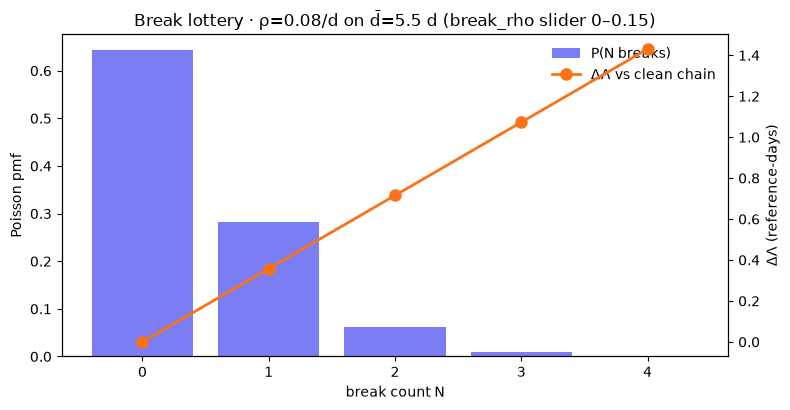

In [3]:
rho = RHO_DEF
tau_bar = TAU_BAR_DEF
phi_set = PHI_SET_DEF
phi_brk = PHI_BREAK_DEF
mu = rho * D_BAR
ns = np.arange(0, 5)
pmf = poisson.pmf(ns, mu)
delta_lam = [lambda_with_breaks(D_BAR, int(n), tau_bar, phi_set, phi_brk) - lambda_clean(D_BAR, phi_set) for n in ns]

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(ns, pmf, color="#6366f1", alpha=0.85, label="P(N breaks)")
ax.set_xlabel("break count N")
ax.set_ylabel("Poisson pmf")
ax.set_xticks(ns)
ax2 = ax.twinx()
ax2.plot(ns, delta_lam, "o-", color="#f97316", lw=2, ms=8, label="ΔΛ vs clean chain")
ax2.set_ylabel("ΔΛ (reference-days)")
ax.set_title(f"Break lottery · ρ={rho:.2f}/d on d̄={D_BAR} d (break_rho slider 0–0.15)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

## Chart 3 — `transit_temp_bias_c` → Heat tax

The studio `transit_temp_bias_c` knob (−2…+8 °C) uniformly shifts every leg setpoint — an exploration offset for “what if the reefer ran warm?”. Duration-weighted **φ_set(ΔT)** is the operating point on the Arrhenius curve **φ(T) = q10^((T−T_ref)/10)**; it feeds Λ ≈ d_med·φ_set for a clean chain at median transit **d_med = 5.5 d**.

The curve is pure Q10; the blue dot tracks the biased operating point (T̄_set + ΔT, φ_set). The red dot height encodes **P(f = 0 | Λ)** at that Λ — one `gammaincc` call. No trace generation, no `truth_transit_trace`.

| Variable | Role |
|----------|------|
| `transit_temp_bias_c` | Studio slider (−2…+8 °C); sketch uses **0 °C** |
| `φ(T)` | Q10 temperature factor (`store_temp_factor`) |
| `φ_set` | Σ w_k φ(T_k + ΔT) over legs |
| `d_med` | 5.5 d fixed median transit |
| `P(f=0\|Λ)` | `gamma_q(kΛ, 1/θ)` at Λ = d_med·φ_set |


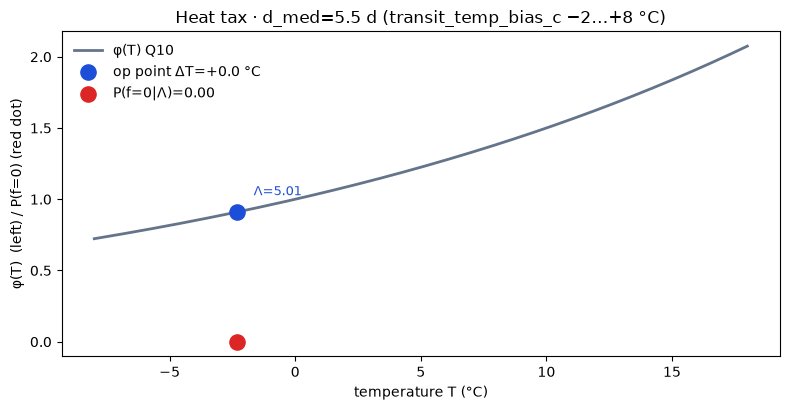

In [4]:
bias_c = 0.0
phi_set = phi_set_from_legs(ARTIFACT, bias_c)
t_op = mean_setpoint_c(ARTIFACT, bias_c)
lam = lambda_clean(D_MED, phi_set)
p0 = p_f_zero(lam)

t_grid = np.linspace(-8, 18, 200)
phi_curve = phi(t_grid)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(t_grid, phi_curve, color="#64748b", lw=2, label="φ(T) Q10")
ax.scatter([t_op], [phi_set], s=120, color="#1d4ed8", zorder=4, label=f"op point ΔT={bias_c:+.1f} °C")
ax.scatter([t_op], [p0], s=120, color="#dc2626", zorder=4, label=f"P(f=0|Λ)={p0:.2f}")
ax.annotate(
    f"Λ={lam:.2f}",
    xy=(t_op, phi_set),
    xytext=(12, 12),
    textcoords="offset points",
    fontsize=9,
    color="#1d4ed8",
)
ax.set_xlabel("temperature T (°C)")
ax.set_ylabel("φ(T)  (left) / P(f=0) (red dot)")
ax.set_title(f"Heat tax · d_med={D_MED} d (transit_temp_bias_c −2…+8 °C)")
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## Chart 4 — `tau_bar` → Λ waterfall

Mean break duration **τ̄** (`tau_bar` slider, 0.1–1.5 d) scales how much exposure each break event adds: E[break add-on] = **ρ·d·τ̄·(φ_break − φ_set)** on top of the clean **d·φ_set** bar. At fixed **d = 5.5 d** and **ρ = 0.08**, sweeping τ̄ moves the middle bar while the decomposition stays closed form.

Stacked bars show clean baseline, expected break add-on, and total Λ; bar colour maps **E[f | Λ_total]** so longer breaks read as warmer/faded fruit. One scalar gamma mean per τ̄ — still no Prior rebake.

| Variable | Role |
|----------|------|
| `tau_bar` | Studio slider (0.1–1.5 d); sketch highlights **0.5 d** |
| `d`, `ρ` | Fixed 5.5 d, 0.08 / day |
| `d·φ_set` | Clean-chain Λ component |
| `E[break add-on]` | `ρ·d·τ̄·(φ_break − φ_set)` |
| colour | `E[f\|Λ_total]` at expected Λ |


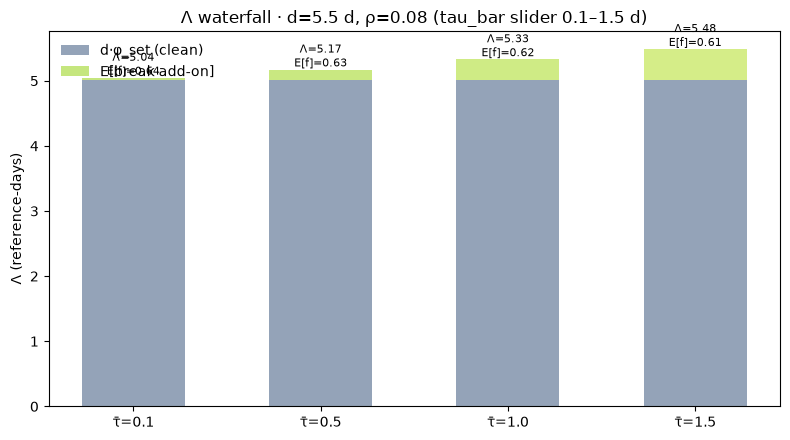

In [5]:
rho = RHO_DEF
phi_set = PHI_SET_DEF
phi_brk = PHI_BREAK_DEF
tau_grid = np.array([0.1, 0.5, 1.0, 1.5])
clean = D_MED * phi_set
addons = rho * D_MED * tau_grid * break_exposure_rate(phi_set, phi_brk)
totals = clean + addons
mean_fs = [mean_f(lam) for lam in totals]
colors = plt.cm.RdYlGn(mean_fs)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(tau_grid))
w = 0.55
ax.bar(x, clean, w, color="#94a3b8", label="d·φ_set (clean)")
ax.bar(x, addons, w, bottom=clean, color=colors, label="E[break add-on]")
for i, (t, tot, mf) in enumerate(zip(tau_grid, totals, mean_fs, strict=True)):
    ax.text(i, tot + 0.05, f"Λ={tot:.2f}\nE[f]={mf:.2f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f"τ̄={t:.1f}" for t in tau_grid])
ax.set_ylabel("Λ (reference-days)")
ax.set_title(f"Λ waterfall · d={D_MED} d, ρ={rho} (tau_bar slider 0.1–1.5 d)")
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## Chart 5 — `T_break` → Break temperature sensitivity

When the cold chain breaks, product sits at **`T_break`** (slider 8–20 °C). Higher break temperature raises **φ_break = φ(T_break)** and therefore the per-day exposure premium **(φ_break − φ_set)** inside Λ. At fixed **d = 5.5 d**, **ρ = 0.08**, **τ̄ = 0.5 d**, expected Λ is closed form and feeds the gamma law.

Two curves trace **P(f = 0 | Λ)** and **P(f < 0.5 | Λ)** vs T_break — a handful of `gammaincc` evaluations along a 1-D grid. This replaces MC break traces for the Preview tier sensitivity view.

| Variable | Role |
|----------|------|
| `T_break` | Studio slider (8–20 °C); sketch marks **12 °C** default |
| `φ_break` | `φ(T_break)` |
| `Λ` | `lambda_expected(d, ρ, τ̄, φ_set, φ_break)` |
| `P(f=0)`, `P(f<0.5)` | Gamma tail probabilities at Λ |


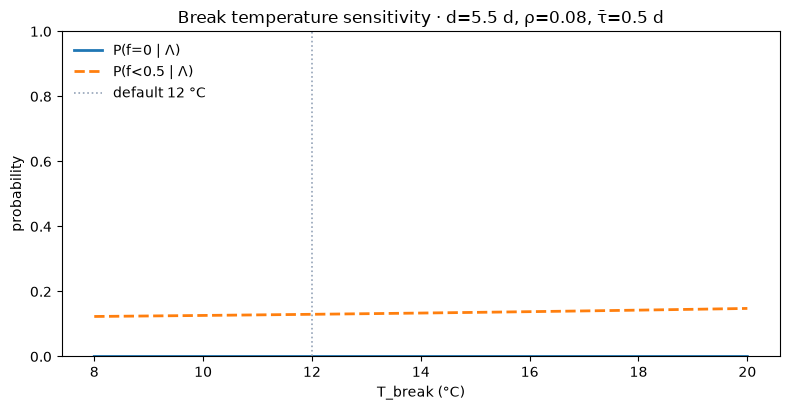

In [6]:
rho = RHO_DEF
tau_bar = TAU_BAR_DEF
phi_set = PHI_SET_DEF
t_breaks = np.linspace(8, 20, 49)
p0s = []
p_lo = []
for tb in t_breaks:
    lam = lambda_expected(D_MED, rho, tau_bar, phi_set, phi_break(float(tb)))
    p0s.append(p_f_zero(lam))
    p_lo.append(p_f_below(lam, 0.5))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(t_breaks, p0s, lw=2, label="P(f=0 | Λ)")
ax.plot(t_breaks, p_lo, lw=2, ls="--", label="P(f<0.5 | Λ)")
ax.axvline(T_BREAK_DEF, color="#94a3b8", ls=":", lw=1.2, label=f"default {T_BREAK_DEF:.0f} °C")
ax.set_xlabel("T_break (°C)")
ax.set_ylabel("probability")
ax.set_ylim(0, 1)
ax.set_title(f"Break temperature sensitivity · d={D_MED} d, ρ={rho}, τ̄={tau_bar} d")
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()